<img src="https://www.darshan.ac.in/Content/media/DU_Logo.svg" width="200"/>

# Machine Learning Project – 
<h1>Task 2: Data Cleaning & Exploratory Data Analysis (EDA)<h1></h1>
<h2>## Cardiovascular Disease Prediction System</h2>



1.Check for missing values in the dataset.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
data = pd.read_csv('cardio_train.csv',sep=';')
data

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


1.Check for missing values in the dataset.

In [4]:
data.isnull().sum()


id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

2.Handle Missing Value 

In [5]:
data.fillna(data.median(), inplace=True)
data

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


3.Detect Outlier

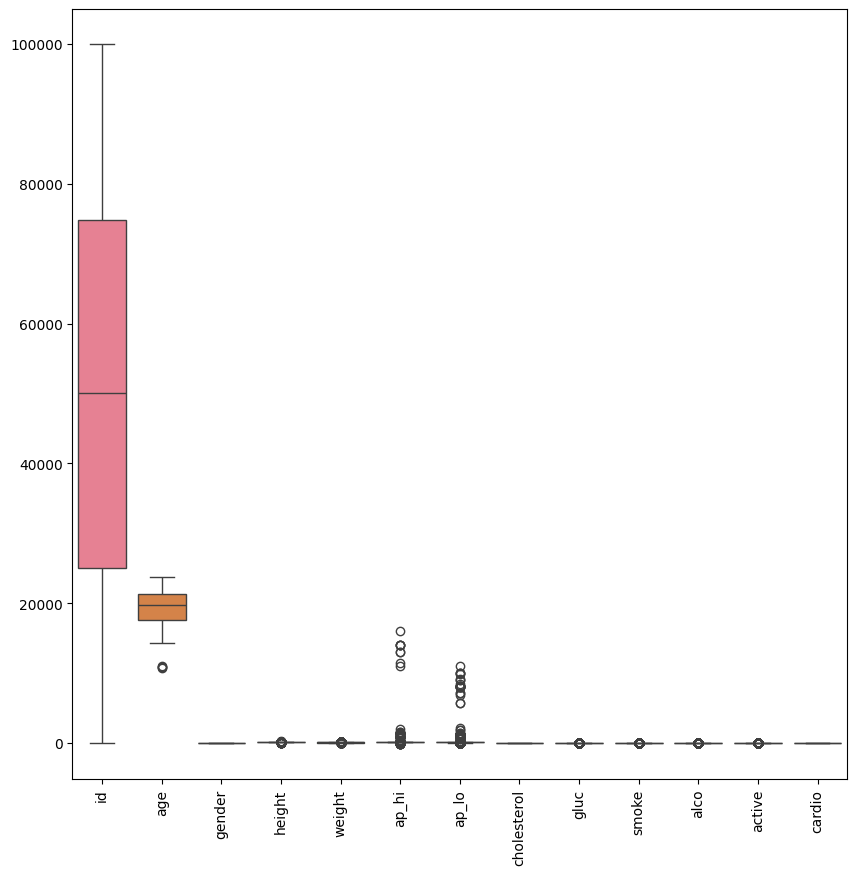

In [6]:
plt.figure(figsize=(10,10))
sns.boxplot(data=data)
plt.xticks(rotation=90)
plt.show()

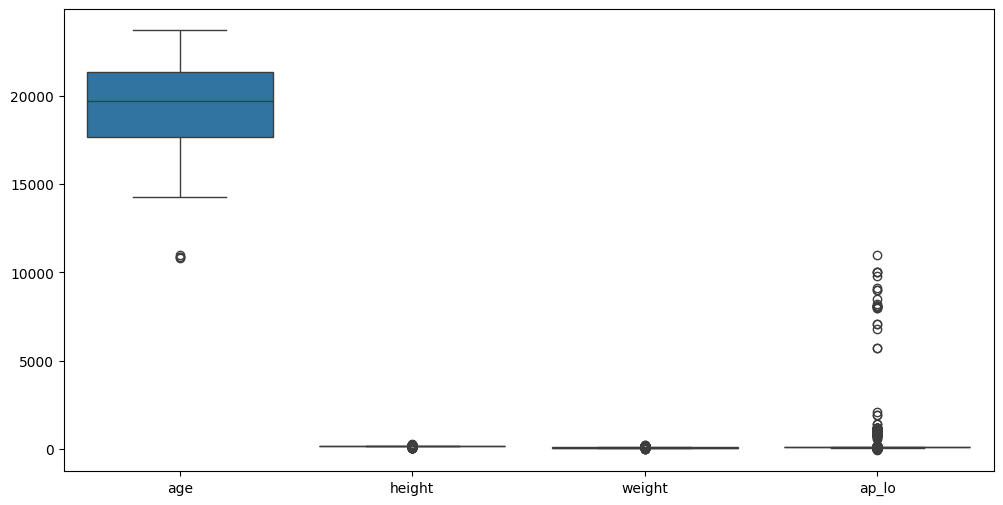

In [7]:
plt.figure(figsize=(12,6))
sns.boxplot(data=data[['age','height','weight','ap_lo']])
plt.show()

<Axes: ylabel='weight'>

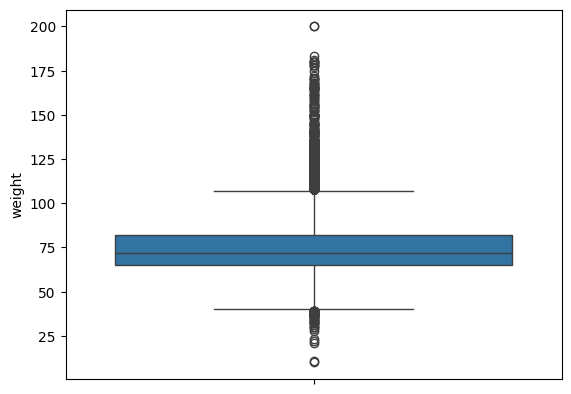

In [8]:
sns.boxplot(data['weight'])

4.Correlation vs target

In [9]:
data.corr()['cardio'].sort_values(ascending=False)

cardio         1.000000
age            0.238159
cholesterol    0.221147
weight         0.181660
gluc           0.089307
ap_lo          0.065719
ap_hi          0.054475
gender         0.008109
id             0.003799
alco          -0.007330
height        -0.010821
smoke         -0.015486
active        -0.035653
Name: cardio, dtype: float64

5.Check target variable distribution

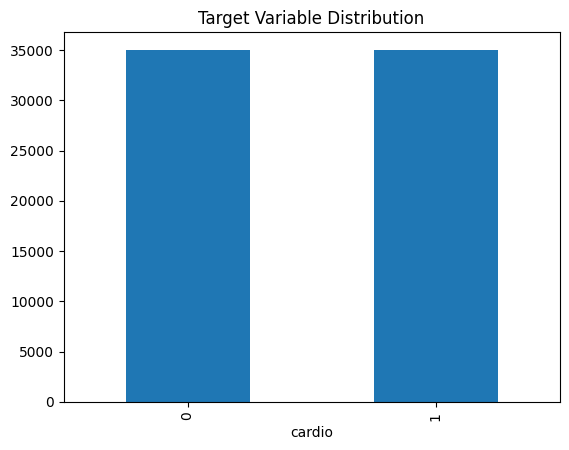

In [10]:
data['cardio'].value_counts().plot(kind='bar')
plt.title("Target Variable Distribution")
plt.show()

6.Correlation heatmap

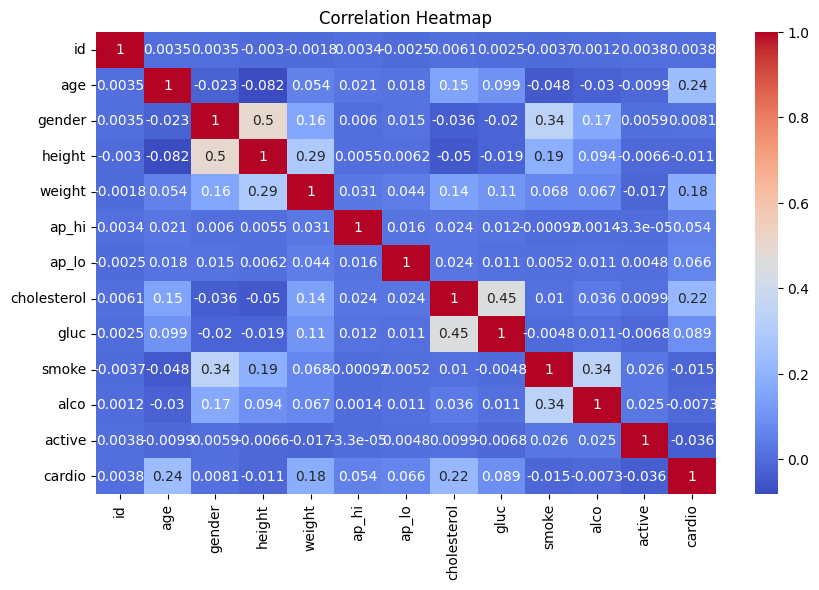

In [11]:

plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

7.Distribution plots

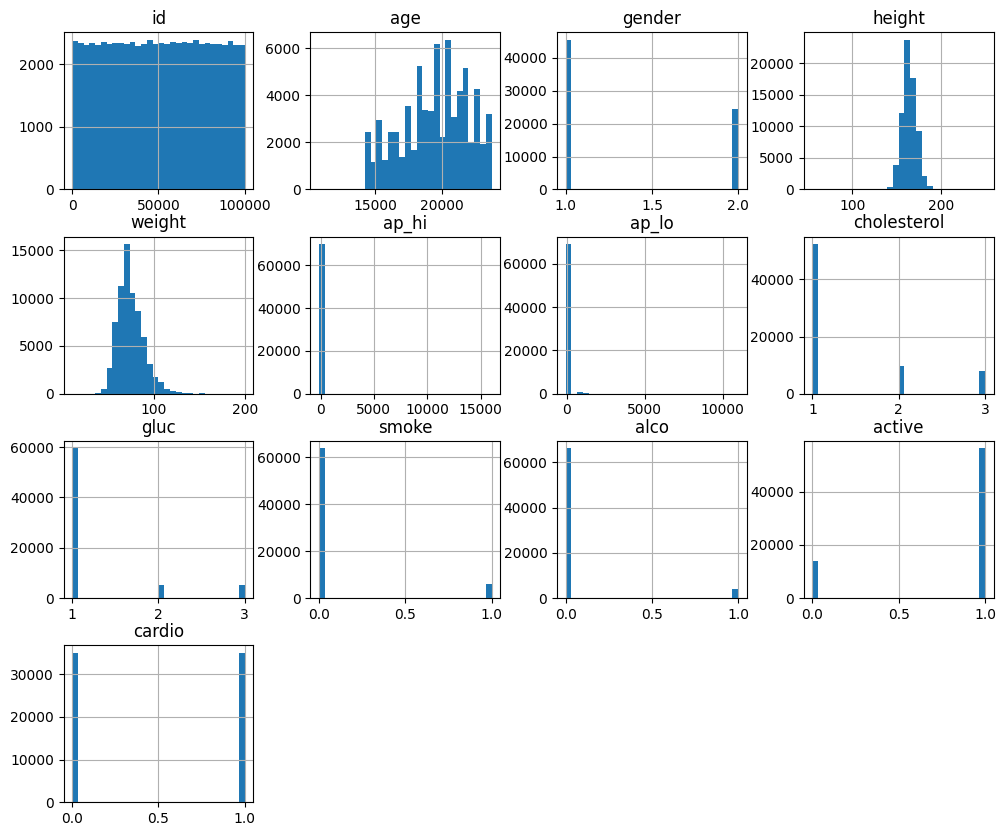

In [12]:
data.hist(figsize=(12,10), bins=30)
plt.show()

8.Convert age from days to years.

In [13]:
data['age_years'] = (data['age'] / 365).astype(int)
data.drop('age', axis=1, inplace=True)
data.head()


,id,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,0,2,168,62.0,110,80,1,1,0,0,1,0,50
1,1,1,156,85.0,140,90,3,1,0,0,1,1,55
2,2,1,165,64.0,130,70,3,1,0,0,0,1,51
3,3,2,169,82.0,150,100,1,1,0,0,1,1,48
4,4,1,156,56.0,100,60,1,1,0,0,0,0,47


9.Identify outliers in blood pressure values.

In [14]:
data[['ap_hi', 'ap_lo']].describe()


,ap_hi,ap_lo
count,70000.000000,70000.000000
mean,128.817286,96.630414
std,154.011419,188.472530
min,-150.000000,-70.000000
25%,120.000000,80.000000
50%,120.000000,80.000000
75%,140.000000,90.000000
max,16020.000000,11000.000000


10.Remove invalid blood pressure outliers.

In [15]:
data = data[(data['ap_hi'] > 80) & (data['ap_hi'] < 250)]
data = data[(data['ap_lo'] > 40) & (data['ap_lo'] < 150)]


11.Plot age vs cardiovascular disease.

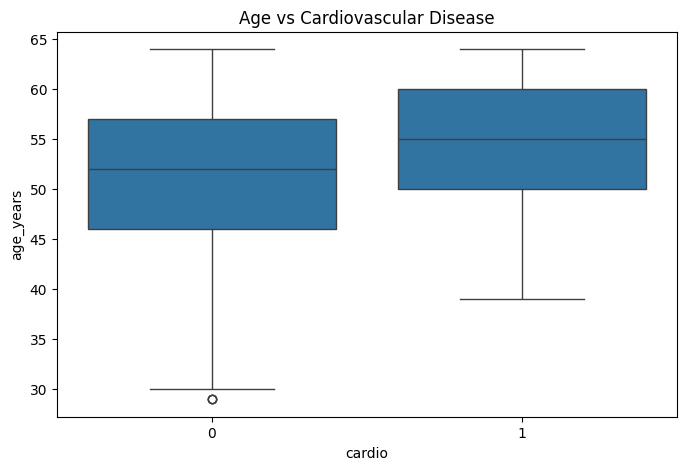

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x='cardio', y='age_years', data=data)
plt.title("Age vs Cardiovascular Disease")
plt.show()


12.Cholesterol Impact

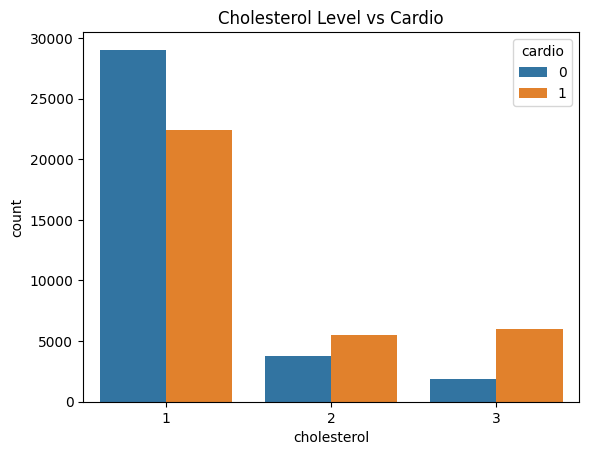

In [17]:
sns.countplot(x='cholesterol', hue='cardio', data=data)
plt.title("Cholesterol Level vs Cardio")
plt.show()

13.Blood Pressure Analysis

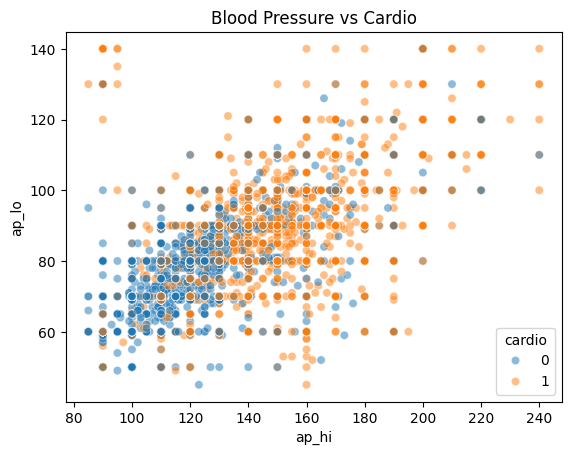

In [18]:
sns.scatterplot(x='ap_hi', y='ap_lo', hue='cardio', data=data, alpha=0.5)                       
plt.title("Blood Pressure vs Cardio")
plt.show()